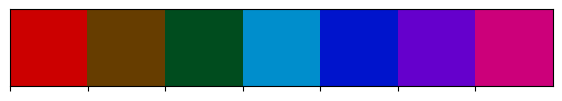

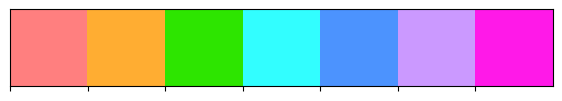

In [46]:
import torch
import os
import sys
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt
import time
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.wrappers.env_wrappers import WallObs, WindowViewObs, ObsToImage, MultiChannel
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [47]:
from src.network_analysis import get_features, _true_reward_from_obs, generate_half_room_states
mse_loss = torch.nn.MSELoss()
def mean_95ci(data):
    """
    Calculate mean and 95% confidence interval using t-distribution.
    
    Parameters:
        data (list or array): Numeric data
        
    Returns:
        tuple: (mean, lower_95, upper_95)
    """
    data = np.array(data)
    n = len(data)
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # sample standard deviation
    se = std / np.sqrt(n)       # standard error
    
    t_critical = scipy.stats.t.ppf(0.95, df=n-1)  # two-tailed 95%
    margin = t_critical * se
    
    lower = mean - margin
    upper = mean + margin
    
    return mean, lower, upper

def bootstrap_ci_2d(data, stat_function=np.mean, n_bootstrap=1000, ci=95):
    """
    Computes bootstrap confidence intervals for each row of a 2D array (axis=1), vectorized.

    Parameters:
        data (array-like): 2D sample data of shape (n_rows, n_samples).
        stat_function (function): Function to compute the statistic along axis=1 (default: np.mean).
                                  Must support axis argument.
        n_bootstrap (int): Number of bootstrap resamples (default: 1000).
        ci (float): Confidence level (default: 95 for a 95% confidence interval).

    Returns:
        np.ndarray: Array of shape (n_rows, 2), where each row is [lower_bound, upper_bound].
    """
    data = np.asarray(data)
    n_rows, n_samples = data.shape

    # Generate all bootstrap sample indices at once
    resample_idx = np.random.randint(0, n_samples, size=(n_bootstrap, n_samples))

    # Gather samples: shape (n_rows, n_bootstrap, n_samples)
    boot_samples = data[:, resample_idx]

    # Compute statistics along the sample axis
    boot_stats = stat_function(boot_samples, axis=1)  # shape (n_rows, n_bootstrap)

    # Confidence interval percentiles
    lower_percentile = (100 - ci) / 2
    upper_percentile = 100 - lower_percentile

    lower_bounds = np.percentile(boot_stats, lower_percentile, axis=0)
    upper_bounds = np.percentile(boot_stats, upper_percentile, axis=0)

    return np.column_stack((lower_bounds, upper_bounds))

In [111]:
device = "mps:0"
grid_size = [10, 10]
eps_decay = 0.0001
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
n_rows, n_colums = grid_size

n_checks = 23
n_ep = 10
n_seeds = 10

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/cacti_room/window_{}/eps_decay_{}/q_lr_{}/reward_lr_{}".format(
    n_rows, n_colums, dryness, window_size, eps_decay, q_lr, r_lr)

reward_models, q_models = [], []
for seed in range(n_seeds):
    # for check in range(n_checks):
    q_models.append(torch.load(main_dir + "/q_network_{}".format(seed), map_location=torch.device(device), weights_only=False))
    reward_models.append(torch.load(main_dir + "/reward_model_{}".format(seed), map_location=torch.device(device), weights_only=False))

obs_mon = torch.tensor(np.squeeze(np.load(main_dir + "/monitor_obs.npy")), dtype=torch.float32)
obs_env = torch.tensor(np.squeeze(np.load(main_dir + "/env_obs.npy")), dtype=torch.float32)

In [4]:
all_states = torch.tensor([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # empty cell          → water: -0.2
    [1.0, 0.5, 0.5, 0.0, 0.0, 0.0],  # plant, watered      → water: -1.0
    [1.0, 0.5, 0.5, 0.0, 0.5, 0.0],  # plant, half dry     → water: +1.0
    [1.0, 0.5, 0.5, 0.0, 1.0, 0.0],  # plant, fully dry    → water: +1.0
])

In [5]:
ture_rewards = _true_reward_from_obs(all_states)

In [6]:
predicted_reward = reward_models[4](all_states.to(device)).detach().cpu().numpy()

In [7]:
np.round(predicted_reward, 3)

array([[ 0.   , -0.   , -0.   ,  0.   , -0.2  ,  0.   ],
       [ 0.   ,  0.   , -0.   ,  0.   , -0.996,  0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ]], dtype=float32)

In [7]:
mon_state = obs_env[1, obs_mon[0] == 1] 
unmon_state = obs_env[1, obs_mon[0] == 0] 

In [8]:
predicted_reward = reward_models[4]((unmon_state[:, :, 5, 5] / torch.tensor([1, 2, 2, 2, 1, 1])).to(device)).detach().cpu()
_true_reward_from_obs(unmon_state[:, :, 5, 5])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000, -0.2000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000, -1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000, -0.2000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000]])

In [9]:
np.round(predicted_reward.numpy(), 3)

array([[ 0.   ,  0.   , -0.   ,  0.   , -0.996,  0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [ 0.   , -0.   , -0.   ,  0.   , -0.2  ,  0.   ],
       [ 0.   ,  0.   , -0.   ,  0.   , -0.996,  0.   ],
       [ 0.   , -0.   , -0.   ,  0.   , -0.2  ,  0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ],
       [-0.   ,  0.   , -0.   ,  0.   ,  1.   , -0.   ]], dtype=float32)

In [71]:
a = generate_half_room_states(1000)
mon_gen, unmon_gen = a[0][:, :, 5, 5], a[1][:, :, 5, 5]

In [72]:
overgen_list = np.zeros((n_seeds, n_checks))
mon_mse_list, unmon_mse_list = np.zeros((n_seeds, n_checks)), np.zeros((n_seeds, n_checks))
for seed in range(n_seeds):
    for check in range(n_checks):
        reward_model = torch.load(main_dir + "/checkpoints_{}/reward_model_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        mon_mse = mse_loss(reward_model(mon_gen.to(device)).detach().cpu(), _true_reward_from_obs(mon_gen))
        unmon_mse = mse_loss(reward_model(unmon_gen.to(device)).detach().cpu(), _true_reward_from_obs(unmon_gen))
        overgen_list[seed, check] =(unmon_mse / mon_mse).item()
        mon_mse_list[seed, check] = mon_mse
        unmon_mse_list[seed, check] = unmon_mse

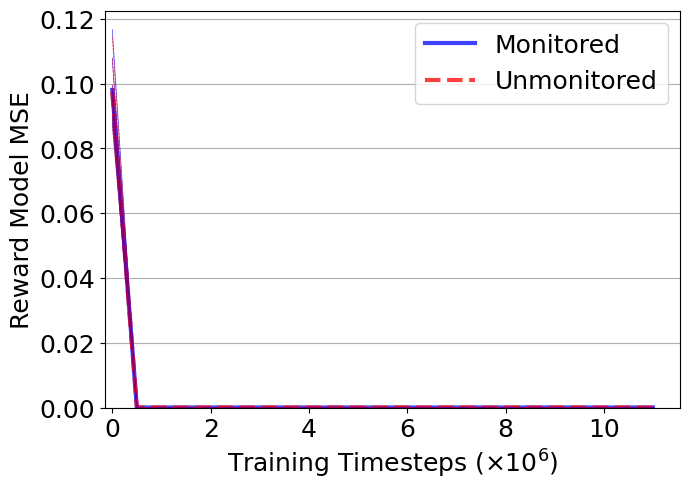

In [74]:
x_axis = np.arange(0, int(n_checks * 5e5), int(5e5)) / 1e6
fig = plt.figure(figsize=(7, 5))
# plt.plot(np.arange(n_checks), np.mean(reward_active, 0), lw=3, color=light_colors[0], label="Reward")
plt.plot(x_axis, np.mean(mon_mse_list, 0), lw=3, color="b", alpha=0.75, label="Monitored")
plt.plot(x_axis, np.mean(unmon_mse_list, 0), "--", lw=3, color="r", alpha=0.75, label="Unmonitored")
# ci_q_model = bootstrap_ci_2d(mon_mse_list, ci=95)
# plt.fill_between(x_axis, ci_q_model[:, 0], ci_q_model[:, 1], color="r", alpha=0.3)

for seed in range(n_seeds):
    plt.plot(x_axis, mon_mse_list[seed], lw=0.5, color="b", alpha=0.75)
    plt.plot(x_axis, unmon_mse_list[seed], "--", lw=0.5, color="r", alpha=0.75)
    
plt.xlabel(r"Training Timesteps ($\times 10^6$)", fontsize=18) #($10^{6}$)
plt.ylabel("Reward Model MSE", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.xlim(-0.15,)
plt.ylim(0,)
plt.legend(fontsize=18)
plt.tight_layout()
# fig.savefig(main_dir + "/reward_model_mse.pdf", dpi=300)

In [112]:
p_c_state = generate_half_room_states(1000,plant_cactus=True)
mon_p_c_state, unmon_p_c_state = p_c_state[0][:, :, 5, 5], p_c_state[1][:, :, 5, 5]

has_vegetation = unmon_p_c_state[:, 1:4].abs().sum(dim=1) > 1e-6
is_cactus = (unmon_p_c_state[:, 3].abs() > 1e-6) & (unmon_p_c_state[:, 1].abs() < 1e-6)
is_plant = has_vegetation & ~is_cactus
is_empty = ~has_vegetation

unmon_plant_states = unmon_p_c_state[is_plant]    # center pixel has a plant
unmon_cactus_states = unmon_p_c_state[is_cactus]  # center pixel has a cactus
unmon_empty_states = unmon_p_c_state[is_empty]    # center pixel is empty

In [113]:
overgen_list = np.zeros((n_seeds, n_checks))
mon_mse_list, unmon_mse_list = np.zeros((n_seeds, n_checks)), np.zeros((n_seeds, n_checks))
plant_unmon, cactus_unmon, empty_unmon = np.zeros((n_seeds, n_checks)), np.zeros((n_seeds, n_checks)), np.zeros((n_seeds, n_checks))
for seed in range(n_seeds):
    for check in range(n_checks):
        reward_model = torch.load(main_dir + "/checkpoints_{}/reward_model_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        mon_mse = mse_loss(reward_model(mon_p_c_state.to(device)).detach().cpu(), _true_reward_from_obs(mon_p_c_state))
        unmon_mse = mse_loss(reward_model(unmon_p_c_state.to(device)).detach().cpu(), _true_reward_from_obs(unmon_p_c_state))
        overgen_list[seed, check] =(unmon_mse / mon_mse).item()
        mon_mse_list[seed, check] = mon_mse
        unmon_mse_list[seed, check] = unmon_mse

        plant_unmon[seed, check] = mse_loss(reward_model(unmon_plant_states.to(device)).detach().cpu(), _true_reward_from_obs(unmon_plant_states))
        cactus_unmon[seed, check] = mse_loss(reward_model(unmon_cactus_states.to(device)).detach().cpu(), _true_reward_from_obs(unmon_cactus_states))
        empty_unmon[seed, check] = mse_loss(reward_model(unmon_empty_states.to(device)).detach().cpu(), _true_reward_from_obs(unmon_empty_states))

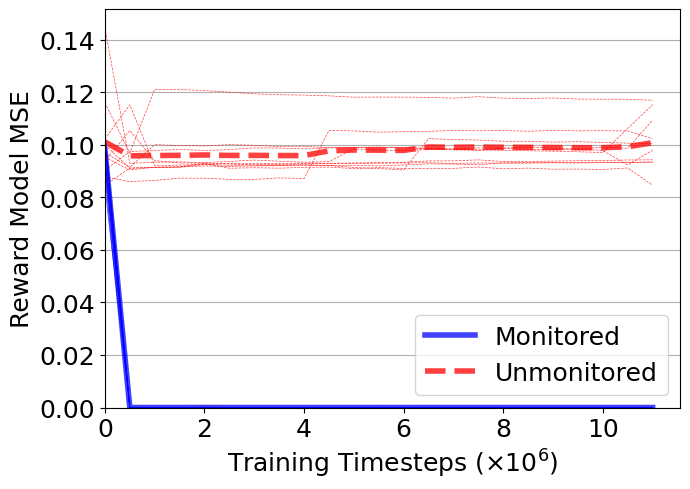

In [114]:
x_axis = np.arange(0, int(n_checks * 5e5), int(5e5)) / 1e6
fig = plt.figure(figsize=(7, 5))
# plt.plot(np.arange(n_checks), np.mean(reward_active, 0), lw=3, color=light_colors[0], label="Reward")
plt.plot(x_axis, np.mean(mon_mse_list, 0), lw=4, color="b", alpha=0.75, label="Monitored")
plt.plot(x_axis, np.mean(unmon_mse_list, 0), "--", lw=4, color="r", alpha=0.75, label="Unmonitored")

for seed in range(n_seeds):
    plt.plot(x_axis, mon_mse_list[seed], lw=0.5, color="b", alpha=0.75)
    plt.plot(x_axis, unmon_mse_list[seed], "--", lw=0.5, color="r", alpha=0.75)
    
plt.xlabel(r"Training Timesteps ($\times 10^6$)", fontsize=18) #($10^{6}$)
plt.ylabel("Reward Model MSE", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.xlim(0,)
plt.ylim(0,)
plt.legend(fontsize=18)
plt.tight_layout()
# fig.savefig(main_dir + "/reward_model_mse.pdf", dpi=300)

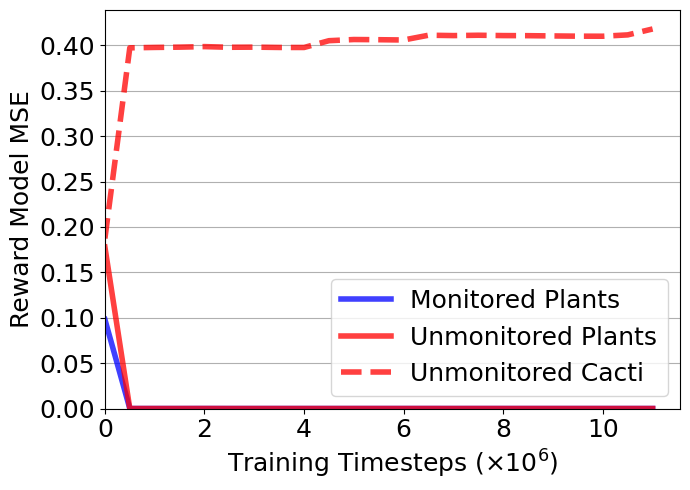

In [116]:
x_axis = np.arange(0, int(n_checks * 5e5), int(5e5)) / 1e6
fig = plt.figure(figsize=(7, 5))
# plt.plot(np.arange(n_checks), np.mean(reward_active, 0), lw=3, color=light_colors[0], label="Reward")
plt.plot(x_axis, np.mean(mon_mse_list, 0), lw=4, color="b", alpha=0.75, label="Monitored Plants")
plt.plot(x_axis, np.mean(plant_unmon, 0), lw=4, color="r", alpha=0.75, label="Unmonitored Plants")
# plt.plot(x_axis, np.mean(empty_unmon, 0), ".", lw=4, color="r", alpha=0.75, label="Unmonitored Empty")
plt.plot(x_axis, np.mean(cactus_unmon, 0), "--", lw=4, color="r", alpha=0.75, label="Unmonitored Cacti")

    
plt.xlabel(r"Training Timesteps ($\times 10^6$)", fontsize=18) #($10^{6}$)
plt.ylabel("Reward Model MSE", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.xlim(0,)
plt.ylim(0,)
# plt.legend(fontsize=18)
plt.tight_layout()
# fig.savefig(main_dir + "/per_plant_reward_model_mse.pdf", dpi=300)

In [130]:
np.std(overgen_list[:, -1]) /1e13

6.832719570595605

In [102]:
2050959564/1e9

2.050959564

In [126]:
np.std(overgen_list[:, -1] / 1e5)

683271957.0595604